In [40]:
import sys
print(sys.version)

3.11.15 (main, Jun  2 2026, 22:26:03) [Clang 22.1.3 ]


In [41]:
from base import SolveResult
from pathlib import Path
from typing import Any
import matplotlib.pyplot as plt

plt.style.use('default')
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'savefig.facecolor': 'white',
    'savefig.edgecolor': 'white'
})

### Evaluate functions

In [42]:
def load_runs(dir: Path) -> dict[str, Any]:
    import re
    import json
    files = dir.glob("*.json")
    files = sorted(files, key=lambda f: int(re.search(r"\d+", f.name).group()))
    # results = {f.stem: SolveResult.model_validate_json(f.read_text()) for f in files}
    # return results
    runs = {f.stem: json.loads(f.read_text()) for f in files}
    return runs

def measure_tool_correctness(runs: dict[str, Any]):
    from agentic_ai.tools import ALL_TAUBENCH_TOOLS

    correctness = {}
    
    for tool in ALL_TAUBENCH_TOOLS:
        correctness[tool.name] = {
            "correct": 0,
            "wrong": 0,
            "missing": 0,
            "extra": 0,
            "all": 0,
            "score": 0.0 # score = correct / all
        }

    for k, v in runs.items():
        correctness_ = v["info"]["reward_info"]["info"]["correctness"]
        actions_ = v["info"]["reward_info"]["actions"]

        for a in correctness_["correct"]:
            if not a or a["name"] == "respond" or a["name"] not in correctness.keys(): continue
            correctness[a["name"]]["correct"] += 1

        for a in correctness_["wrong"]:
            if not a or a["name"] == "respond" or a["name"] not in correctness.keys(): continue
            correctness[a["name"]]["wrong"] += 1

        for a in correctness_["miss"]:
            if not a or a["name"] == "respond" or a["name"] not in correctness.keys(): continue
            correctness[a["name"]]["missing"] += 1

        for a in correctness_["extra"]:
            if not a or a["name"] == "respond" or a["name"] not in correctness.keys(): continue
            correctness[a["name"]]["extra"] += 1

        for a in actions_:
            if not a or a["name"] == "respond" or a["name"] not in correctness.keys(): continue
            correctness[a["name"]]["all"] += 1

    for tool_name, tool_corr in correctness.items():
        try:
            correctness[tool_name]["score"] = tool_corr["correct"] / tool_corr["all"]
        except ZeroDivisionError as e:
            correctness[tool_name]["score"] = None
    
    return correctness

def measure_reward(runs: dict[str, Any]):
    reward = {
        "reward" : 0.0,
        "reward_actions" : 0.0,
        "reward_outputs": 0.0,
        "score" : 0.0 # score = reward / len(runs)
    }
    for task_name, task_rs in runs.items():
        info = task_rs["info"]["reward_info"]["info"]
        reward["reward"] += info["reward"]
        reward["reward_actions"] += info["r_actions"]
        reward["reward_outputs"] += info["r_outputs"]
    
    reward["score"] = reward["reward"] / len(runs.keys())
        
    return reward

def pass_hat_k(n, c, k):
    """pass^k"""
    import math
    return math.comb(c,k) / math.comb(n,k)

def pass_at_k(n, c, k):
    """pass@k"""
    import math
    return 1 - (math.comb(n-c,k) / math.comb(n,k))

def pass_k(n, c):
    passk = {
        "pass@k": {
            "pass@1": 0.0
        },
        "pass^k": {
            "pass^1": 0.0
        }
    }

    for k in range(1,n+1):
        passk["pass@k"][f"pass@{k}"] = pass_at_k(n,c,k)
        passk["pass^k"][f"pass^{k}"] = pass_hat_k(n,c,k)

    return passk

def evaluate(n_runs: list[dict[str, Any]]):
    stats = {
        "tasks": {},
        "correctness": {},
        "reward": {}
    }

    for i, runs in enumerate(n_runs):
        for task_name, task_rs in runs.items():
            if task_name not in stats["tasks"]:
                stats["tasks"][task_name] = {
                    "n": 0,
                    "c": 0,
                    "passk": None,
                }
            stats["tasks"][task_name]["n"] += 1
            stats["tasks"][task_name]["c"] += 1 if task_rs["reward"] else 0

        for task_name in runs.keys():
            stats["tasks"][task_name]["passk"] = pass_k(
                n=stats["tasks"][task_name]["n"],
                c=stats["tasks"][task_name]["c"]
            )

        stats["correctness"] = measure_tool_correctness(runs)
        stats["reward"] = measure_reward(runs)

    return stats

def plot_correctness(data):
    import numpy as np

    tools = list(data.keys())[::-1]

    scores = []
    colors = []

    for t in tools:
        s = data[t]["score"]
        if s:
            scores.append(s)
            colors.append("orange")
        else:
            scores.append(0)
            colors.append("gray")


    y = np.arange(len(tools))

    plt.figure(figsize=(10,5), dpi=300)

    bars = plt.barh(y, scores, color=colors)

    plt.yticks(y, tools)
    plt.xlim(0, 1)
    plt.xlabel("Score")
    plt.title("Tool Score")
    plt.grid(axis="x", linestyle="--", alpha=0.3)

    for i, bar in enumerate(bars):
        width = bar.get_width()
        
        original = data[tools[i]]["score"]
        label = "N/A" if original is None else f"{width:.2f}"
        
        plt.text(
            width + 0.01,
            bar.get_y() + bar.get_height()/2,
            label,
            va="center",
            ha="left" if width >= 0 else "right"
        )

    plt.tight_layout()
    plt.show()


In [43]:
TOTAL_TASKS = 115

# act_baseline
act_1 = load_runs(Path(".local/act_baseline/run_1/output"))
act_2 = load_runs(Path(".local/act_baseline/run_2/output"))
act_3 = load_runs(Path(".local/act_baseline/run_3/output"))
act_4 = load_runs(Path(".local/act_baseline/run_4/output"))
act_5 = load_runs(Path(".local/act_baseline/run_5/output"))


# act_experimental (with init prompt)
act_e_1 = load_runs(Path(".local/act_experimental/run_1/output"))
act_e_2 = load_runs(Path(".local/act_experimental/run_2/output"))
act_e_3 = load_runs(Path(".local/act_experimental/run_3/output"))
act_e_4 = load_runs(Path(".local/act_experimental/run_4/output"))
act_e_5 = load_runs(Path(".local/act_experimental/run_5/output"))


# plan_and_execute_freeform
plan_1 = load_runs(Path(".local/plan_and_execute_freeform/run_1/output"))
plan_2 = load_runs(Path(".local/plan_and_execute_freeform/run_2/output"))
plan_3 = load_runs(Path(".local/plan_and_execute_freeform/run_3/output"))

# react
react_1 = load_runs(Path(".local/react/run_1/output"))
react_2 = load_runs(Path(".local/react/run_2/output"))
react_3 = load_runs(Path(".local/react/run_3/output"))
react_4 = load_runs(Path(".local/react/run_4/output"))
react_5 = load_runs(Path(".local/react/run_5/output"))



assert len(act_1) == TOTAL_TASKS
assert len(act_2) == TOTAL_TASKS
assert len(act_3) == TOTAL_TASKS
assert len(act_4) == TOTAL_TASKS
assert len(act_5) == TOTAL_TASKS


assert len(act_e_1) == TOTAL_TASKS
assert len(act_e_2) == TOTAL_TASKS
assert len(act_e_3) == TOTAL_TASKS
assert len(act_e_4) == TOTAL_TASKS
# assert len(act_e_5) == TOTAL_TASKS


assert len(plan_1) == TOTAL_TASKS
assert len(plan_2) == TOTAL_TASKS
assert len(plan_3) == TOTAL_TASKS

assert len(react_1) == TOTAL_TASKS
assert len(react_2) == TOTAL_TASKS
assert len(react_3) == TOTAL_TASKS
assert len(react_4) == TOTAL_TASKS
assert len(react_5) == TOTAL_TASKS



In [44]:
act_12345 = [act_1, act_2, act_3, act_4, act_5]
act_e_12345 = [act_e_1, act_e_2, act_e_3, act_e_4, act_e_5]
react_12345 = [react_1, react_2, react_3, react_4, react_5]
plan_123 = [plan_1, plan_2, plan_3]

eval_act_12345 = evaluate(act_12345)
eval_act_e_12345 = evaluate(act_e_12345)
eval_react_12345 = evaluate(react_12345)
eval_plan_123 = evaluate(plan_123)

### Visualize functions

In [45]:
def plot_pass_at_k_dist(data, k_num=1):
    ks = range(1, k_num+1)

    fig, axes = plt.subplots(1, len(ks), figsize=(12, 3), dpi=300, sharey=True)
    
    if len(ks) == 1:
        axes = [axes]

    for i, k in enumerate(ks):
        passk = [v['passk']['pass@k'][f'pass@{k}'] for v in data['tasks'].values()]
        
        axes[i].hist(passk, bins=10, color="gray")
        axes[i].set_title(f"pass@{k} distribution")
        axes[i].set_xlabel(f"pass@{k}")
        axes[i].grid(True, alpha=0.3)

    axes[0].set_ylabel("count")

    plt.tight_layout()
    plt.show()

def plot_pass_hat_k_dist(data, k_num=1):
    ks = range(1, k_num+1)

    fig, axes = plt.subplots(1, len(ks), figsize=(12, 3), dpi=300, sharey=True)
    
    if len(ks) == 1:
        axes = [axes]

    for i, k in enumerate(ks):
        passk = [v['passk']['pass^k'][f'pass^{k}'] for v in data['tasks'].values()]
        
        axes[i].hist(passk, bins=10, color="gray")
        axes[i].set_title(f"pass^{k} distribution")
        axes[i].set_xlabel(f"pass^{k}")
        axes[i].grid(True, alpha=0.3)

    axes[0].set_ylabel("count")

    plt.tight_layout()
    plt.show()

def plot_passk_combined(data, k_num=1):
    ks = range(1, k_num+1)    

    agg_pass = {k: [] for k in ks}
    agg_pass_hat = {k: [] for k in ks}

    for t, v in data['tasks'].items():
        for k in ks:
            agg_pass[k].append(v['passk']['pass@k'][f'pass@{k}'])
            agg_pass_hat[k].append(v['passk']['pass^k'][f'pass^{k}'])

    avg_pass_at = [sum(agg_pass[k]) / len(agg_pass[k]) for k in ks]
    avg_pass_hat = [sum(agg_pass_hat[k]) / len(agg_pass_hat[k]) for k in ks]

    plt.figure(dpi=300, figsize=(8,5))

    plt.plot(ks, avg_pass_at, marker='^', markersize=10, label='pass@k', linestyle='-', color="gray")
    plt.plot(ks, avg_pass_hat, marker='s', markersize=10, label='pass^k', linestyle='-', color="gray")

    plt.title("Average pass@k vs pass^k across tasks")
    plt.xlabel("k")
    plt.ylabel("Score")
    plt.xticks(ks)
    plt.grid(True, linewidth=0.25)
    plt.legend()

    plt.show()

def plot_correctness_score(data):
    names = list(data['correctness'].keys())
    scores = [data['correctness'][n]['score'] or 0 for n in names]

    plt.figure(dpi=300, figsize=(8,5))
    plt.bar(names, scores, color="gray")
    plt.title("Action correctness scores")
    plt.xlabel("Action")
    plt.ylabel("Score")
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

def plot_correctness_stack(data, include_extra=False):
    names = list(data['correctness'].keys())

    correct = [data['correctness'][n]['correct'] for n in names]
    wrong   = [data['correctness'][n]['wrong'] for n in names]
    missing = [data['correctness'][n]['missing'] for n in names]

    if include_extra:
        extra   = [data['correctness'][n]['extra'] for n in names]
        total = [c + w + m + e for c, w, m, e in zip(correct, wrong, missing, extra)]
    else:
        total = [c + w + m for c, w, m in zip(correct, wrong, missing)]

    correct = [c/t if t != 0 else 0 for c, t in zip(correct, total)]
    wrong   = [w/t if t != 0 else 0 for w, t in zip(wrong, total)]
    missing = [m/t if t != 0 else 0 for m, t in zip(missing, total)]
    if include_extra:
        extra   = [e/t if t != 0 else 0 for e, t in zip(extra, total)]

    plt.figure(dpi=300, figsize=(8,5))

    plt.bar(names, correct, label='correct', color="#707070",
            edgecolor='black', linewidth=0.3, hatch="///")

    plt.bar(names, wrong, bottom=correct, label='wrong', color="#a0a0a0",
            edgecolor='black', linewidth=0.3, hatch="...")

    bottom2 = [c + w for c, w in zip(correct, wrong)]
    plt.bar(names, missing, bottom=bottom2, label='missing', color="#eeeeee",
            edgecolor='black', linewidth=0.3, hatch="xxx")

    if include_extra:
        bottom3 = [b + m for b, m in zip(bottom2, missing)]
        plt.bar(names, extra, bottom=bottom3, label='extra', color="#d0d0d0",
                edgecolor='black', linewidth=0.3, hatch="\\\\\\\\")

    plt.title("Action correctenss breakdown")
    plt.xlabel("Action")
    plt.ylabel("Proportion")
    plt.xticks(rotation=45, ha='right')
    plt.legend(bbox_to_anchor=(1, 1), loc='upper left', frameon=False)
    plt.tight_layout()
    plt.show()

#### Images

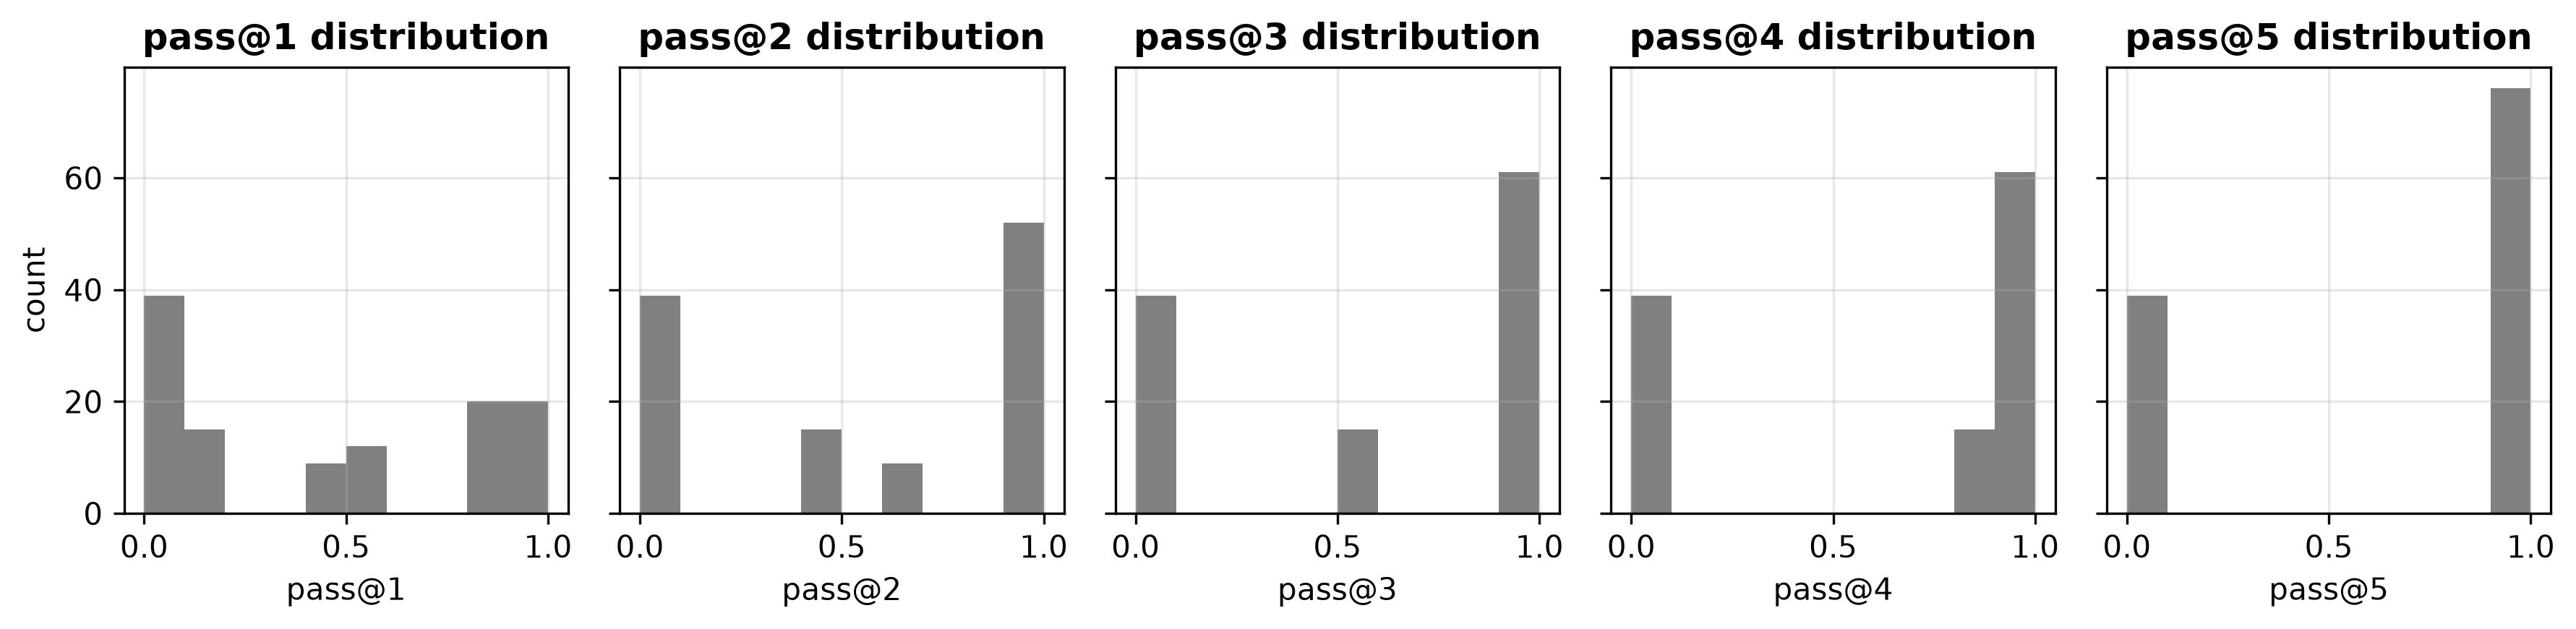

In [46]:
plot_pass_at_k_dist(eval_react_12345, k_num=5)

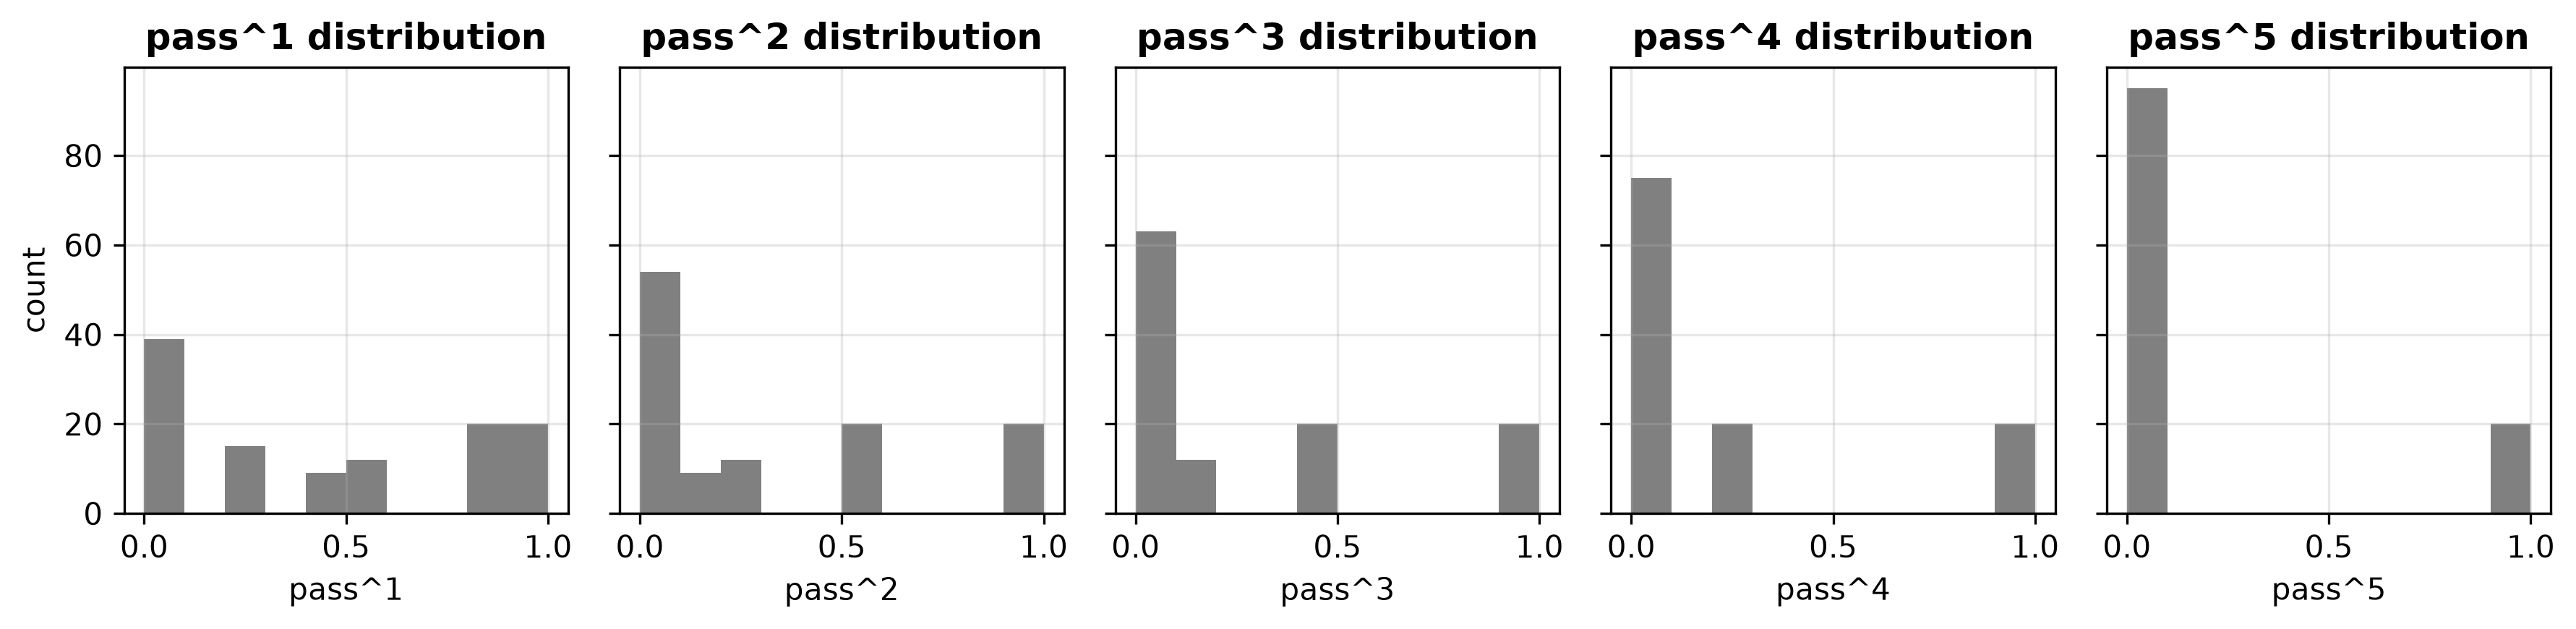

In [47]:
plot_pass_hat_k_dist(eval_react_12345, k_num=5)

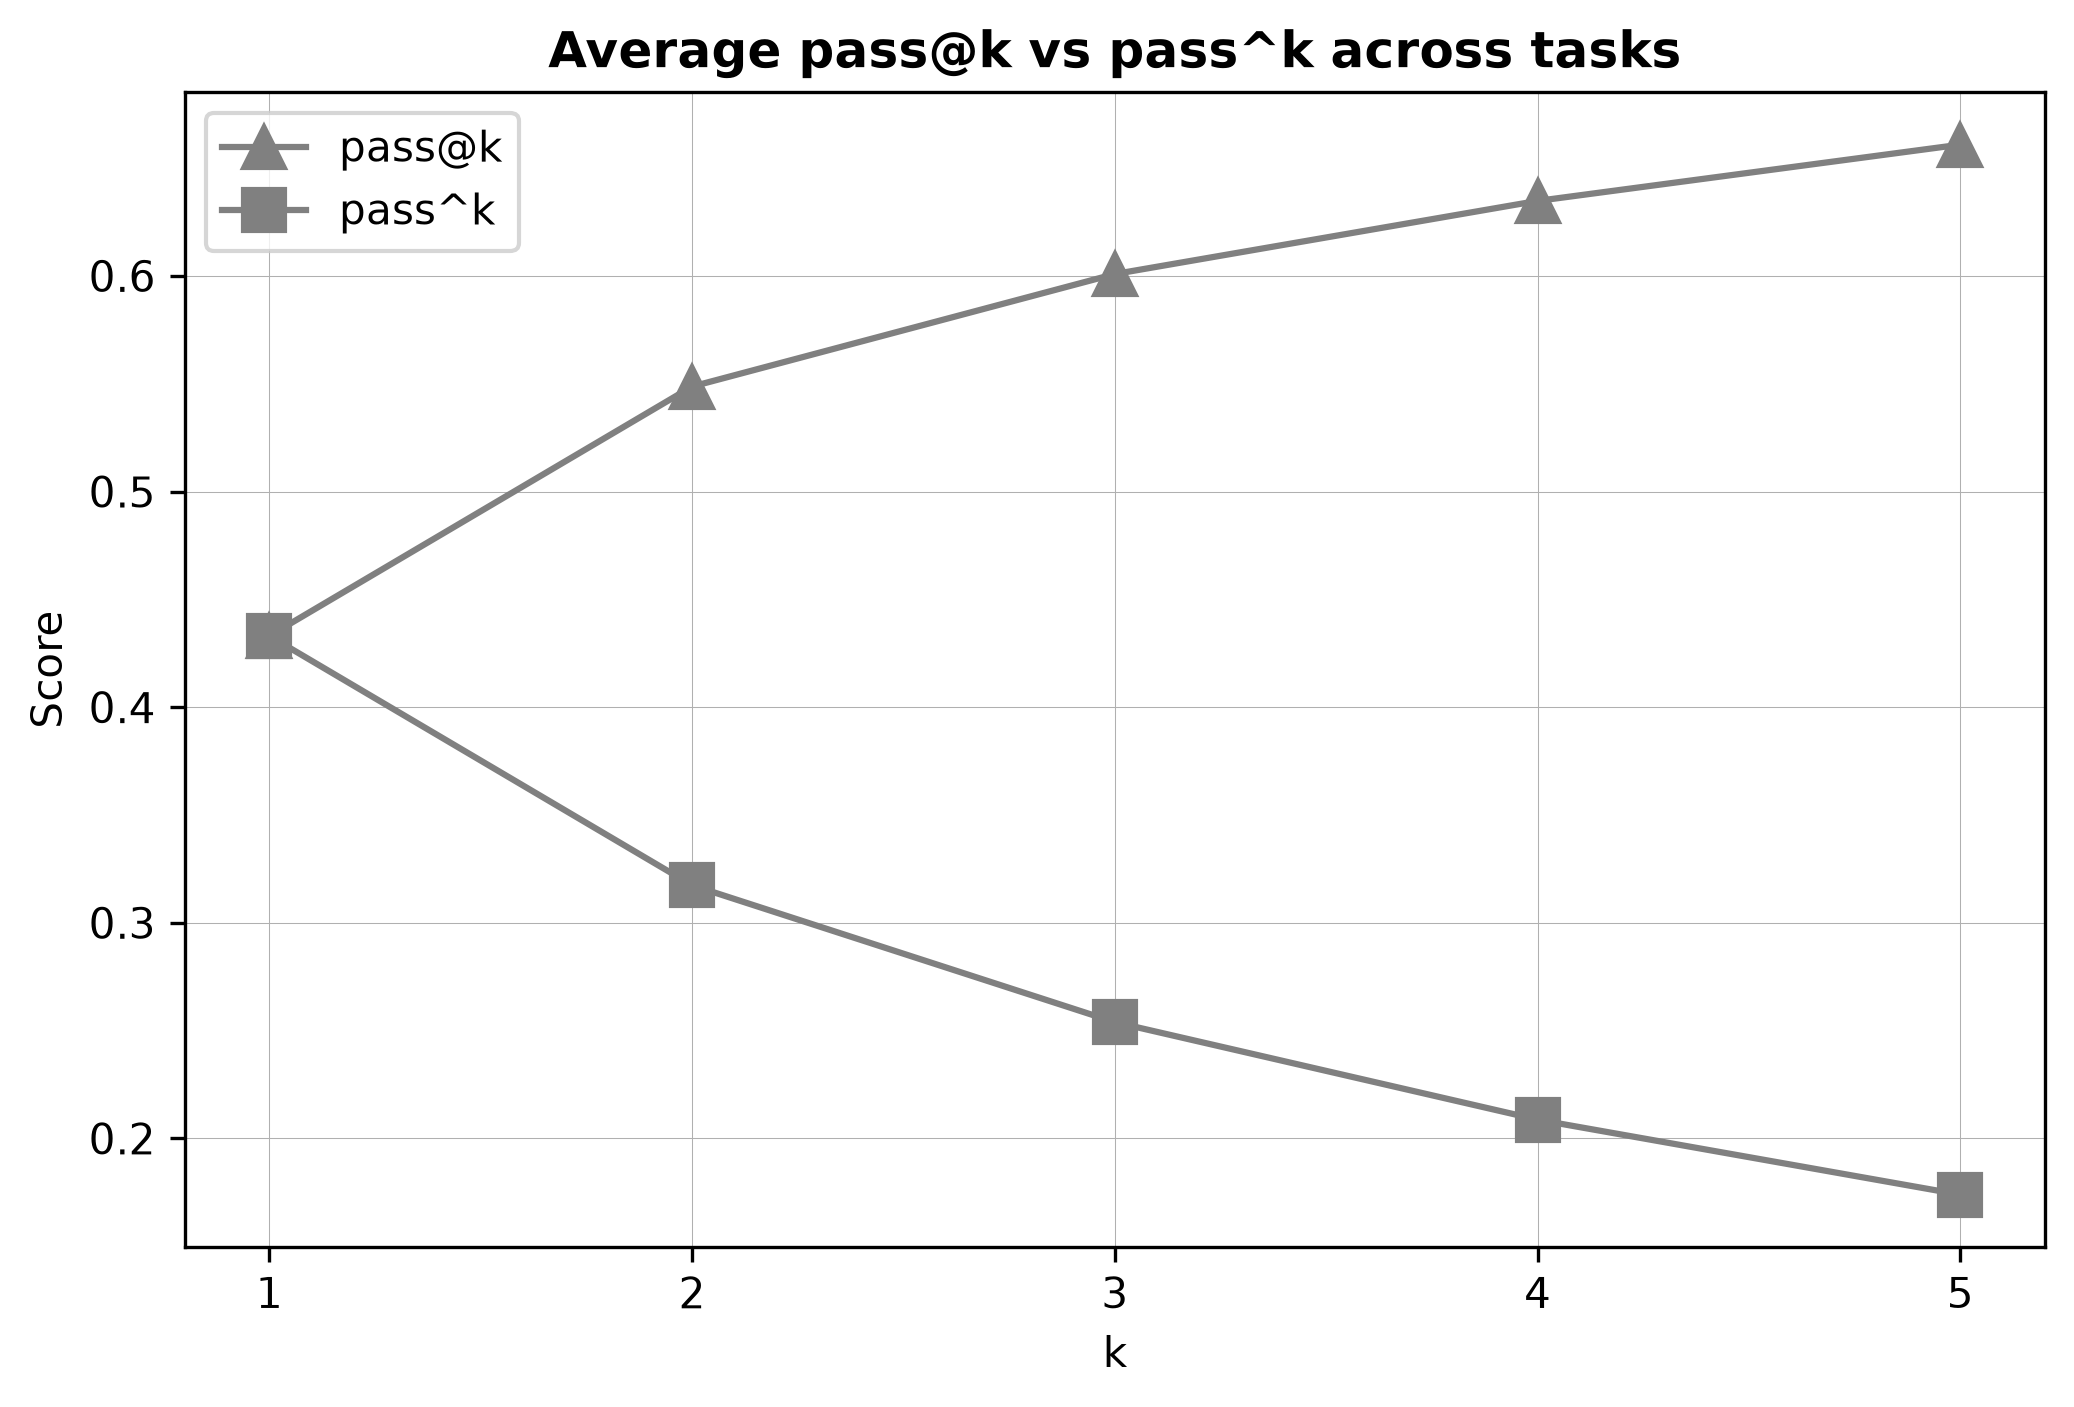

In [48]:
plot_passk_combined(eval_react_12345, k_num=5)

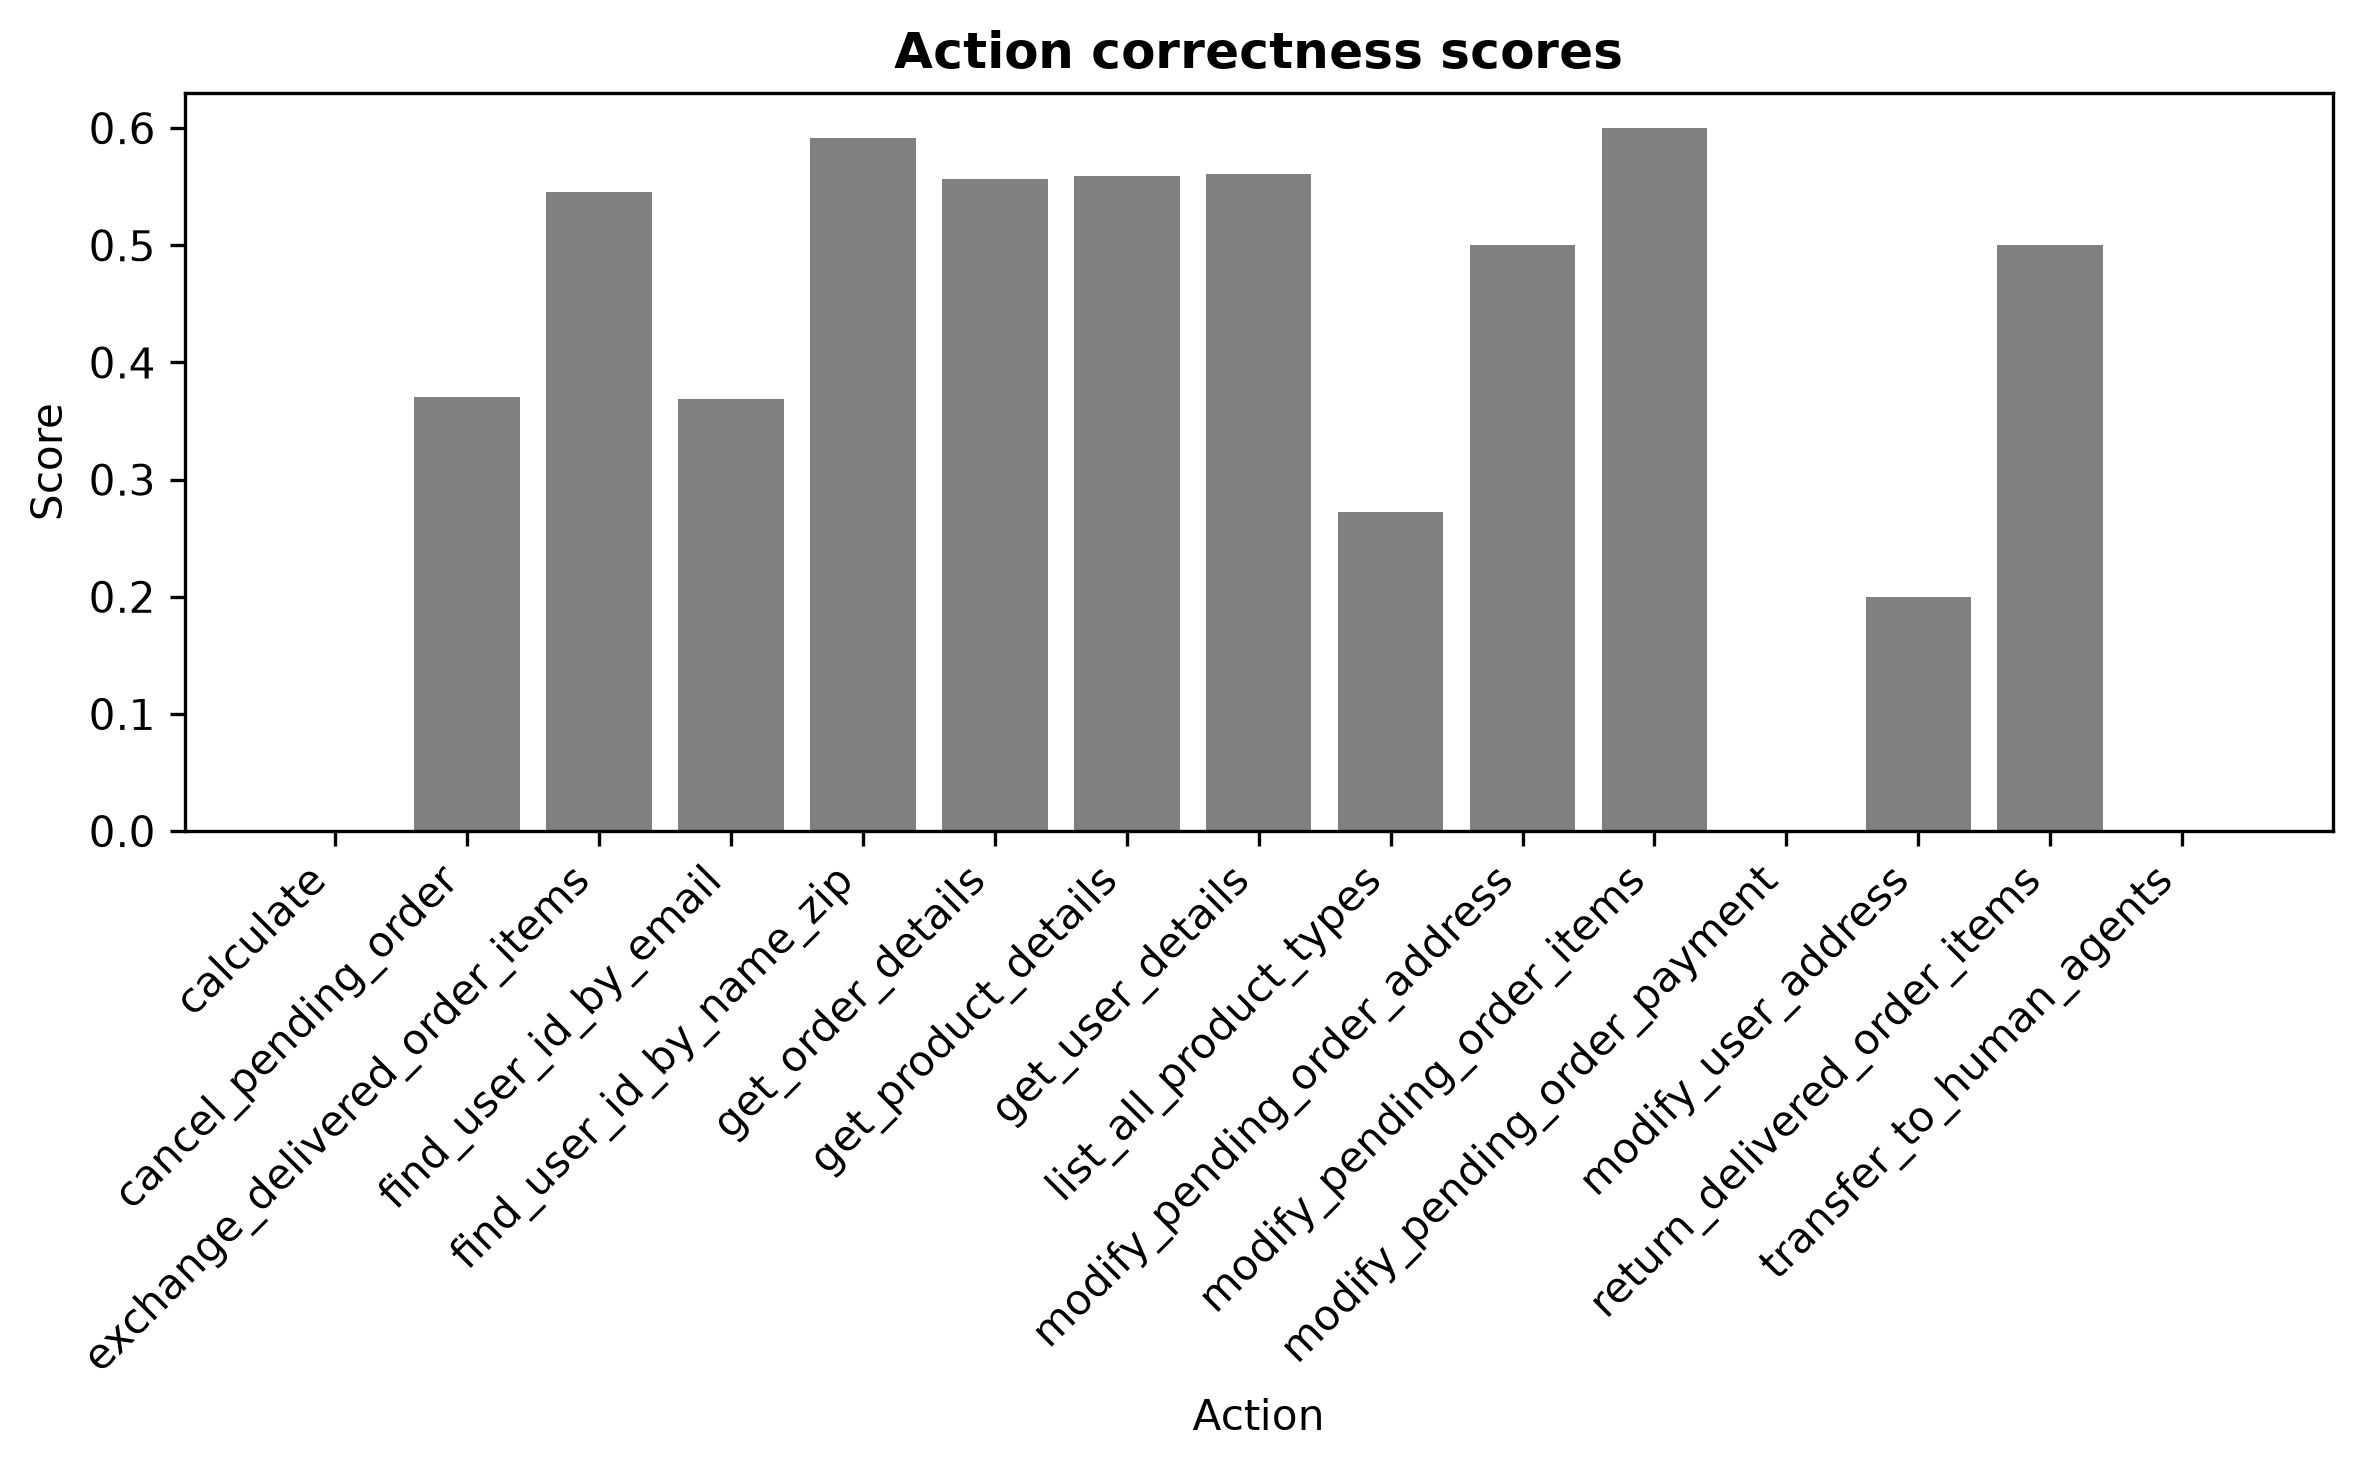

In [49]:
plot_correctness_score(eval_react_12345)

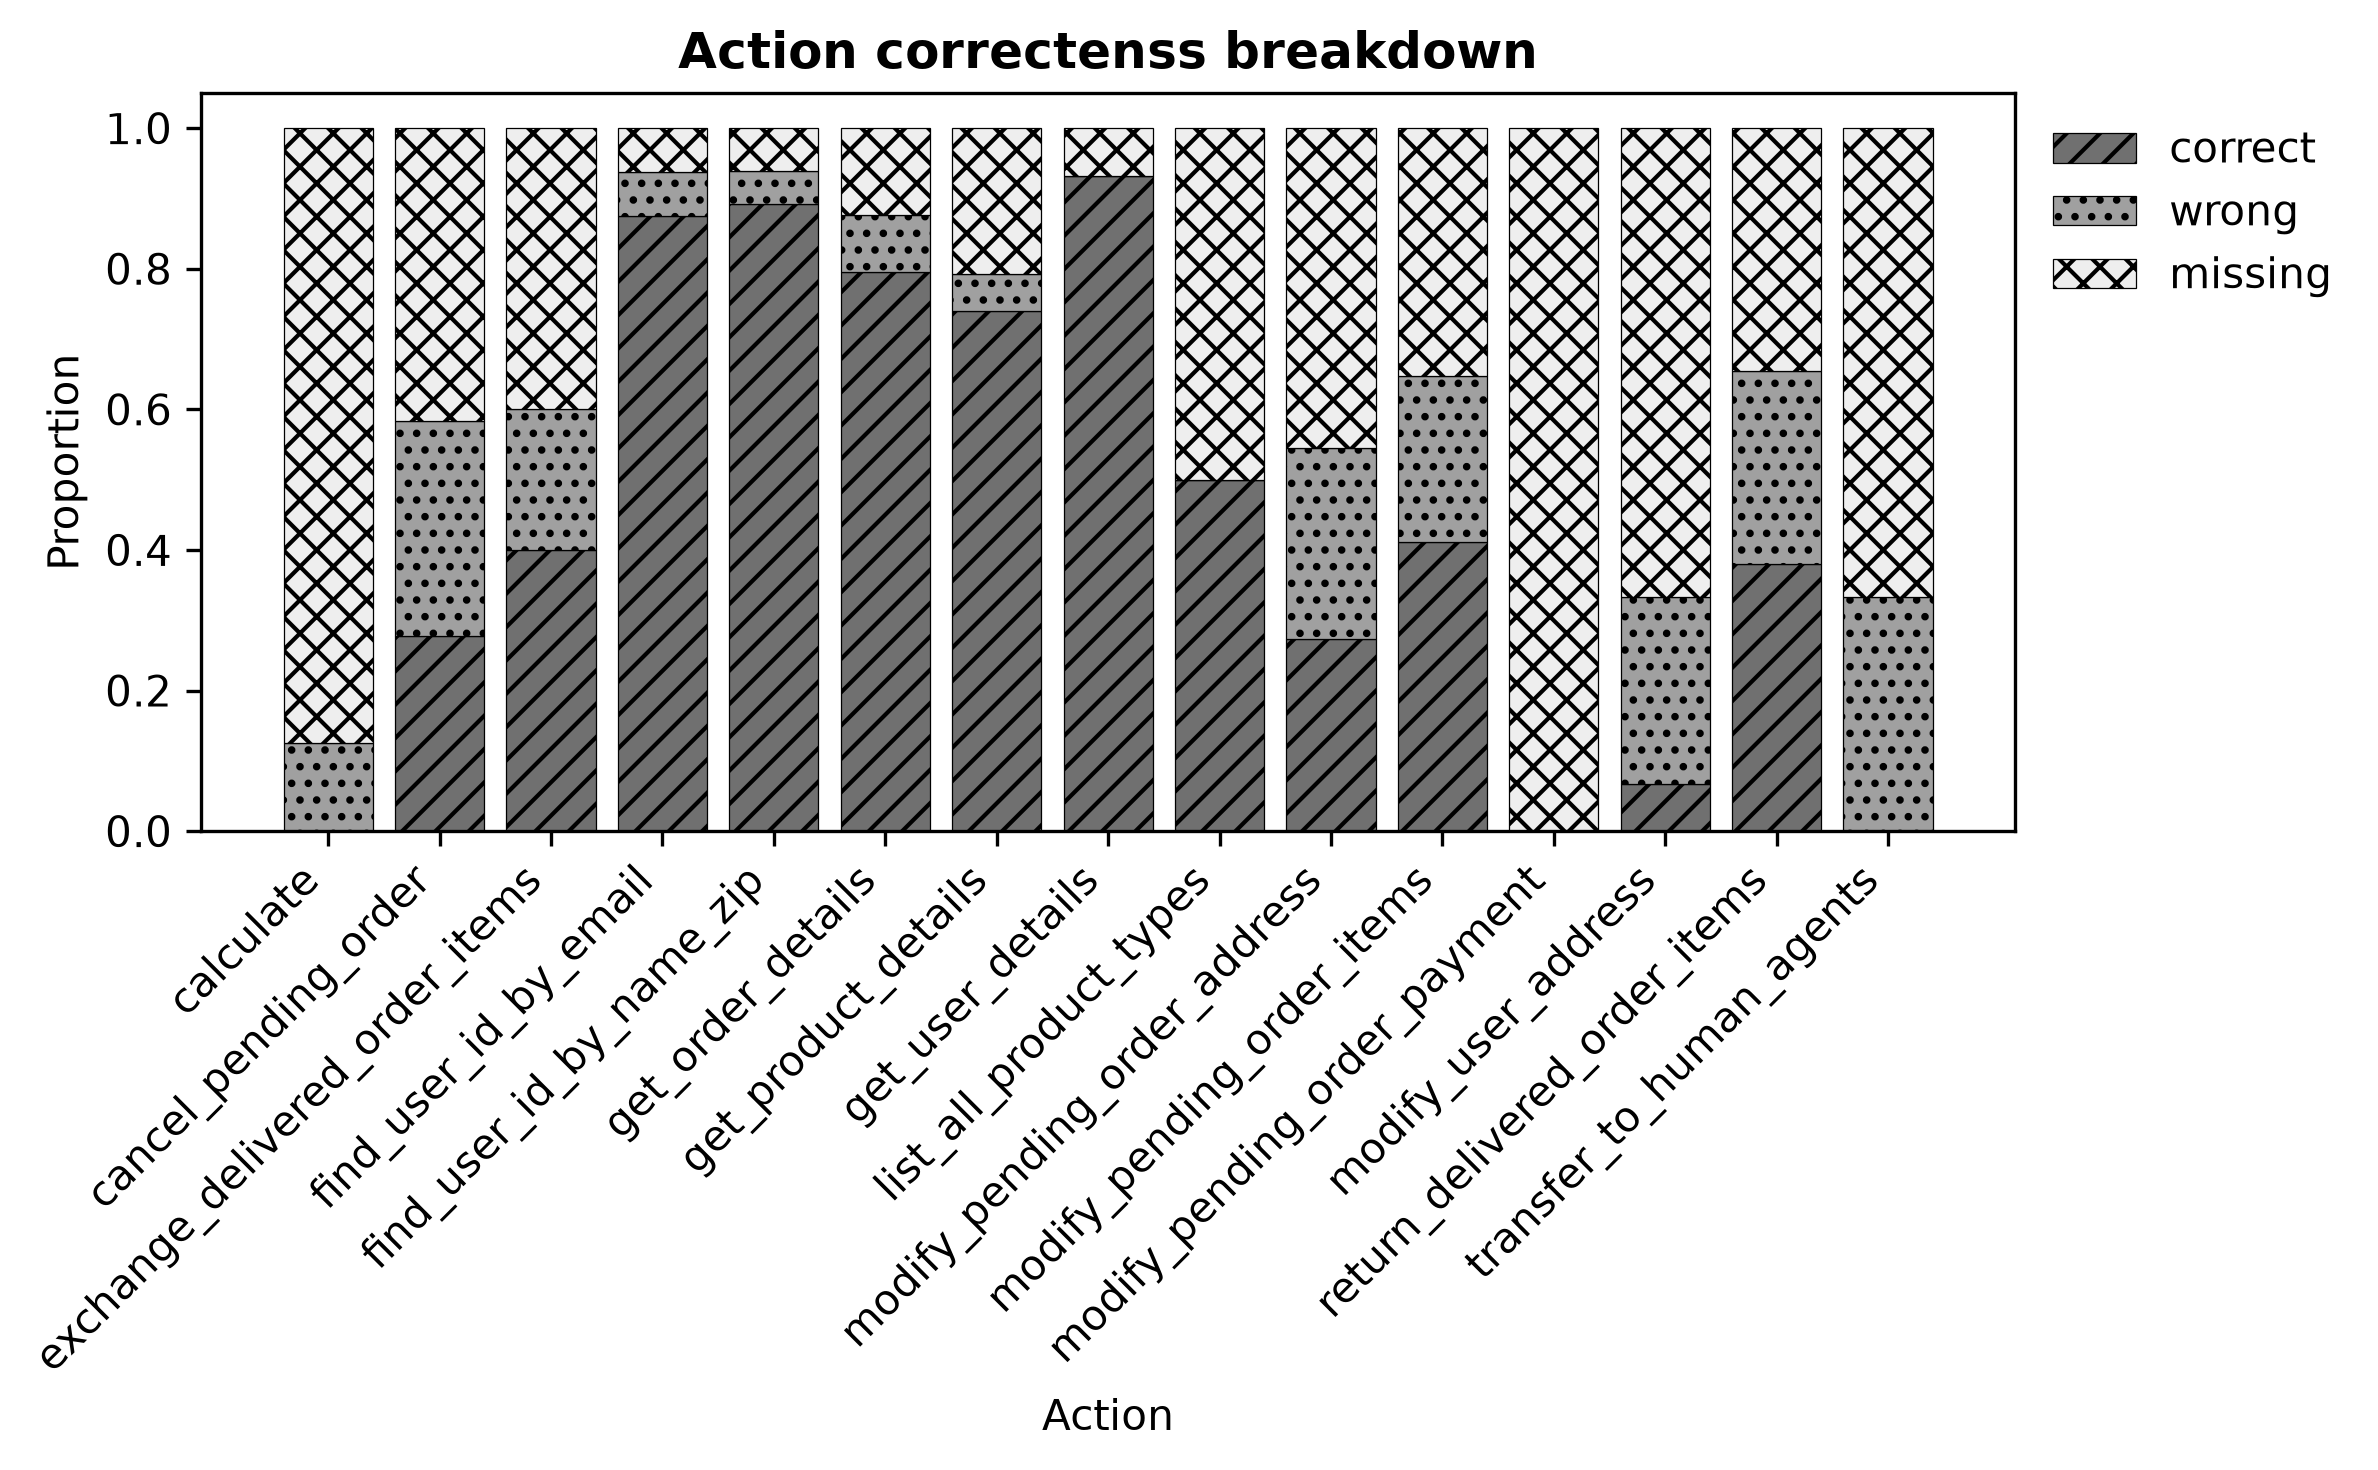

In [50]:
plot_correctness_stack(eval_react_12345)

### Visualize functions (compare A & B)

In [51]:
def plot_compare_reward(data_a, data_b):
    a_color = "lightgray"
    b_color = "lightgray"

    reward_a = data_a['reward']["reward"]
    reward_b = data_b['reward']["reward"]

    plt.figure(figsize=(3,5), dpi=300)
    bar_a = plt.bar('A', reward_a, color=a_color, hatch="", edgecolor="black")
    plt.bar_label(bar_a, fmt="%.2f")
    
    bar_b = plt.bar('B', reward_b, color=b_color, hatch="...", edgecolor="black")
    plt.bar_label(bar_b, fmt="%.2f")
    
    plt.ylabel("Reward")
    plt.title("Reward comparison")
    plt.show()

def plot_compare_pass_at_k_dist(data_a, data_b, *, k_num=1):
    ks = range(1, k_num+1)
    
    fig, axes = plt.subplots(1, len(ks), figsize=(12, 3), dpi=300, sharey=True)
    
    if len(ks) == 1:
        axes = [axes]

    for i, k in enumerate(ks):
        pass_a = [v['passk']['pass@k'][f'pass@{k}'] for v in data_a['tasks'].values()]
        pass_b = [v['passk']['pass@k'][f'pass@{k}'] for v in data_b['tasks'].values()]

        axes[i].hist(
            pass_a,
            bins=10,
            histtype='step',
            linewidth=1.5,
            color='black',
            label='A'
        )

        axes[i].hist(
            pass_b,
            bins=10,
            histtype='step',
            linewidth=1.5,
            color='gray',
            linestyle='--',
            label='B'
        )

        axes[i].set_title(f"pass@{k} distribution")
        axes[i].set_xlabel(f"pass@{k}")
        axes[i].grid(True, alpha=0.3)

    axes[0].set_ylabel("count")

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper center', ncol=2, frameon=False, bbox_to_anchor=(0.5, 0))

    plt.tight_layout()
    plt.show()
    
def plot_compare_pass_hat_k_dist(data_a, data_b, *, k_num=1):
    ks = range(1, k_num+1)

    fig, axes = plt.subplots(1, len(ks), figsize=(12, 3), dpi=300, sharey=True)
    
    if len(ks) == 1:
        axes = [axes]

    for i, k in enumerate(ks):
        pass_a = [v['passk']['pass^k'][f'pass^{k}'] for v in data_a['tasks'].values()]
        pass_b = [v['passk']['pass^k'][f'pass^{k}'] for v in data_b['tasks'].values()]

        axes[i].hist(
            pass_a,
            bins=10,
            histtype='step',
            linewidth=1.5,
            color='black',
            label='A'
        )

        axes[i].hist(
            pass_b,
            bins=10,
            histtype='step',
            linewidth=1.5,
            color='gray',
            linestyle='--',
            label='B'
        )

        axes[i].set_title(f"pass^{k} distribution")
        axes[i].set_xlabel(f"pass^{k}")
        axes[i].grid(True, alpha=0.3)

    axes[0].set_ylabel("count")

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper center', ncol=2, frameon=False, bbox_to_anchor=(0.5, 0))

    plt.tight_layout()
    plt.show()

def plot_compare_passk_combined(data_a, data_b, *, k_num=1):
    ks = range(1, k_num+1)

    a_color = "black"
    b_color = "black"

    def get_avg(data, key):
        agg = {k: [] for k in ks}
        for v in data['tasks'].values():
            for k in ks:
                agg[k].append(v['passk'][f"{key}k"][f'{key}{k}'])
        return [sum(agg[k]) / len(agg[k]) for k in ks]

    avg_a = get_avg(data_a, "pass@")
    avg_b = get_avg(data_b, "pass@")

    avg_hat_a = get_avg(data_a, "pass^")
    avg_hat_b = get_avg(data_b, "pass^")

    plt.figure(dpi=300, figsize=(4,5))

    plt.plot(ks, avg_a, marker='^', markersize=10, linestyle='-', label='A pass@k', color=a_color)
    plt.plot(ks, avg_hat_a, marker='s', markersize=10, linestyle='-', label='A pass^k', color=a_color)

    plt.plot(ks, avg_b, marker='^', markersize=10, linestyle='--', label='B pass@k', color=b_color)
    plt.plot(ks, avg_hat_b, marker='s', markersize=10, linestyle='--', label='B pass^k', color=b_color)

    plt.xlabel("k")
    plt.ylabel("Score")
    plt.title("Comparison: pass@k vs pass^k")
    plt.xticks(ks)
    plt.grid(True, linewidth=0.3)
    plt.legend()
    plt.show()

def plot_compare_correctness_score(data_a, data_b):
    import numpy as np
    names = list(data_a['correctness'].keys())

    a_color = "gray"
    b_color = "lightgray"

    score_a = [data_a['correctness'][n]['score'] or 0 for n in names]
    score_b = [data_b['correctness'][n]['score'] or 0 for n in names]

    x = np.arange(len(names))
    width = 0.4

    plt.figure(dpi=300, figsize=(8,5))

    plt.bar(x - width/2, score_a, width, label="A", color=a_color, hatch="...", edgecolor="black")
    plt.bar(x + width/2, score_b, width, label="B", color=b_color, hatch="", edgecolor="black")

    plt.xticks(x, names, rotation=45, ha='right')
    plt.ylabel("Score")
    plt.title("Correctness score comparison")
    plt.legend()
    plt.tight_layout()
    plt.show()

#### Images

In [53]:
data_a = eval_act_12345
data_b = eval_react_12345

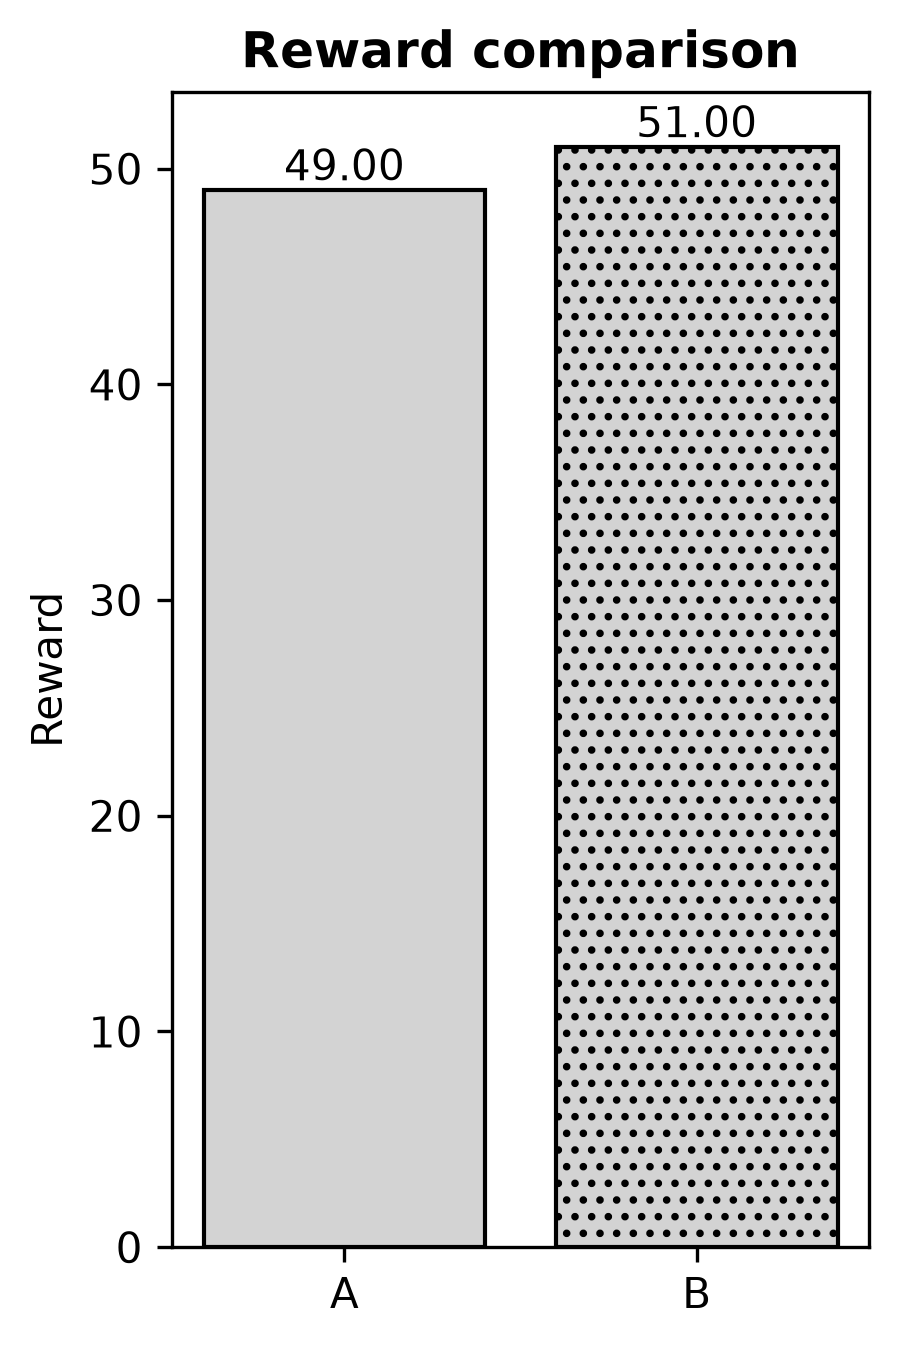

In [ ]:
plot_compare_reward(data_a, data_b)

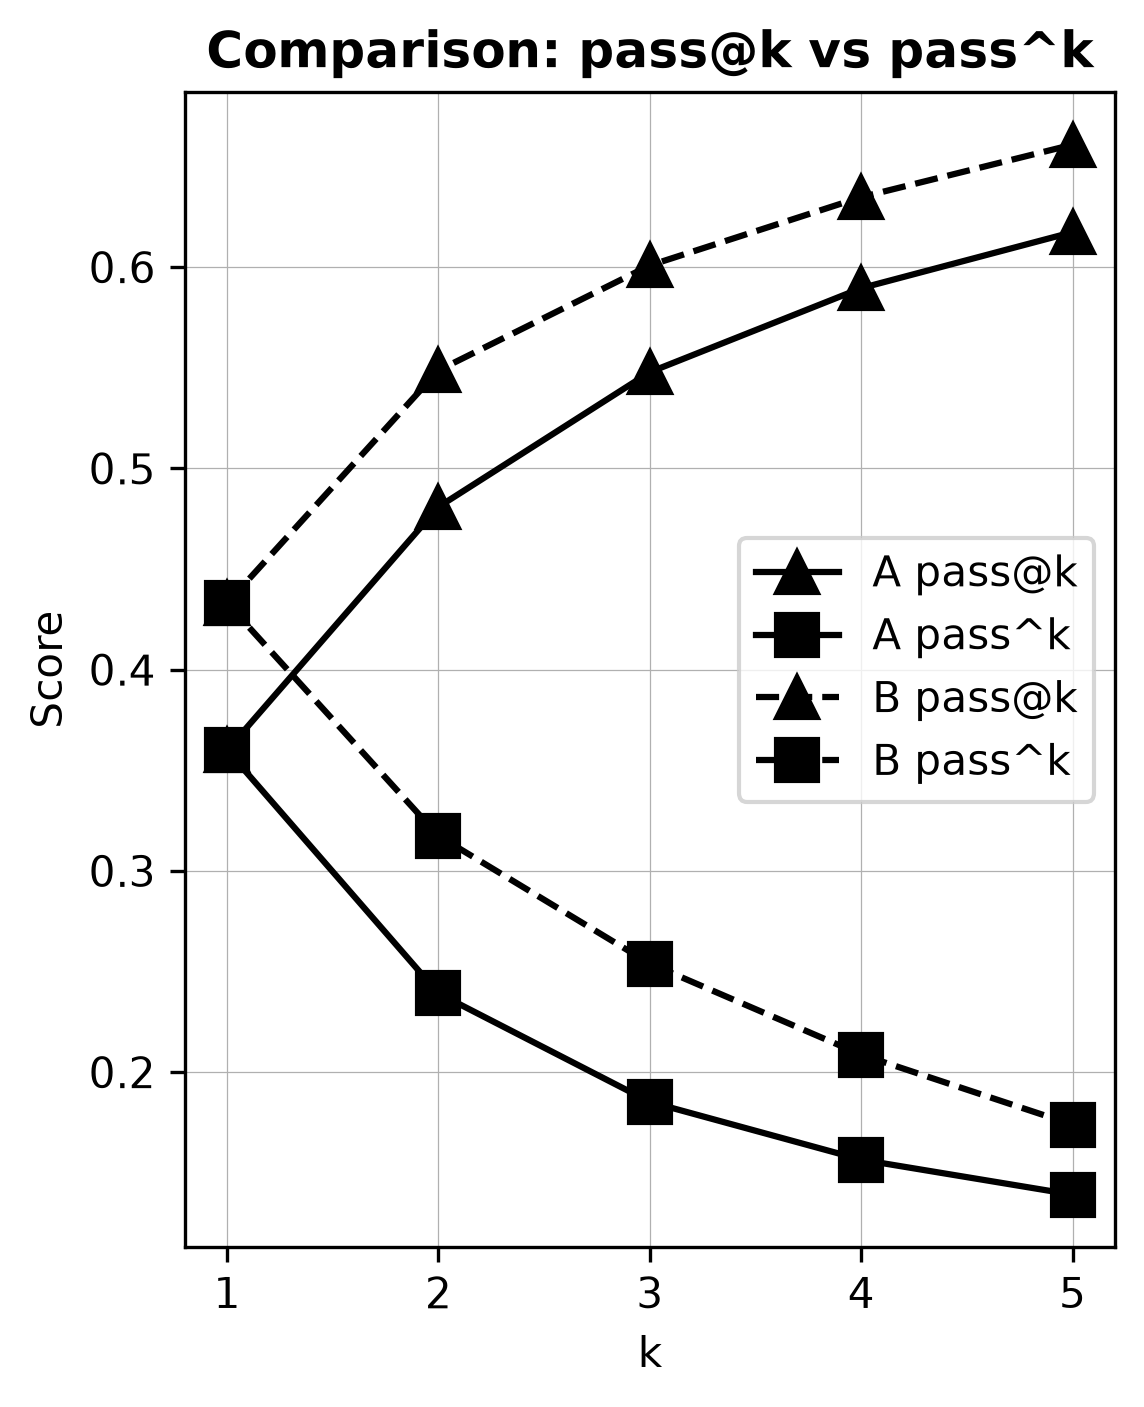

In [59]:
plot_compare_passk_combined(data_a, data_b, k_num=5)

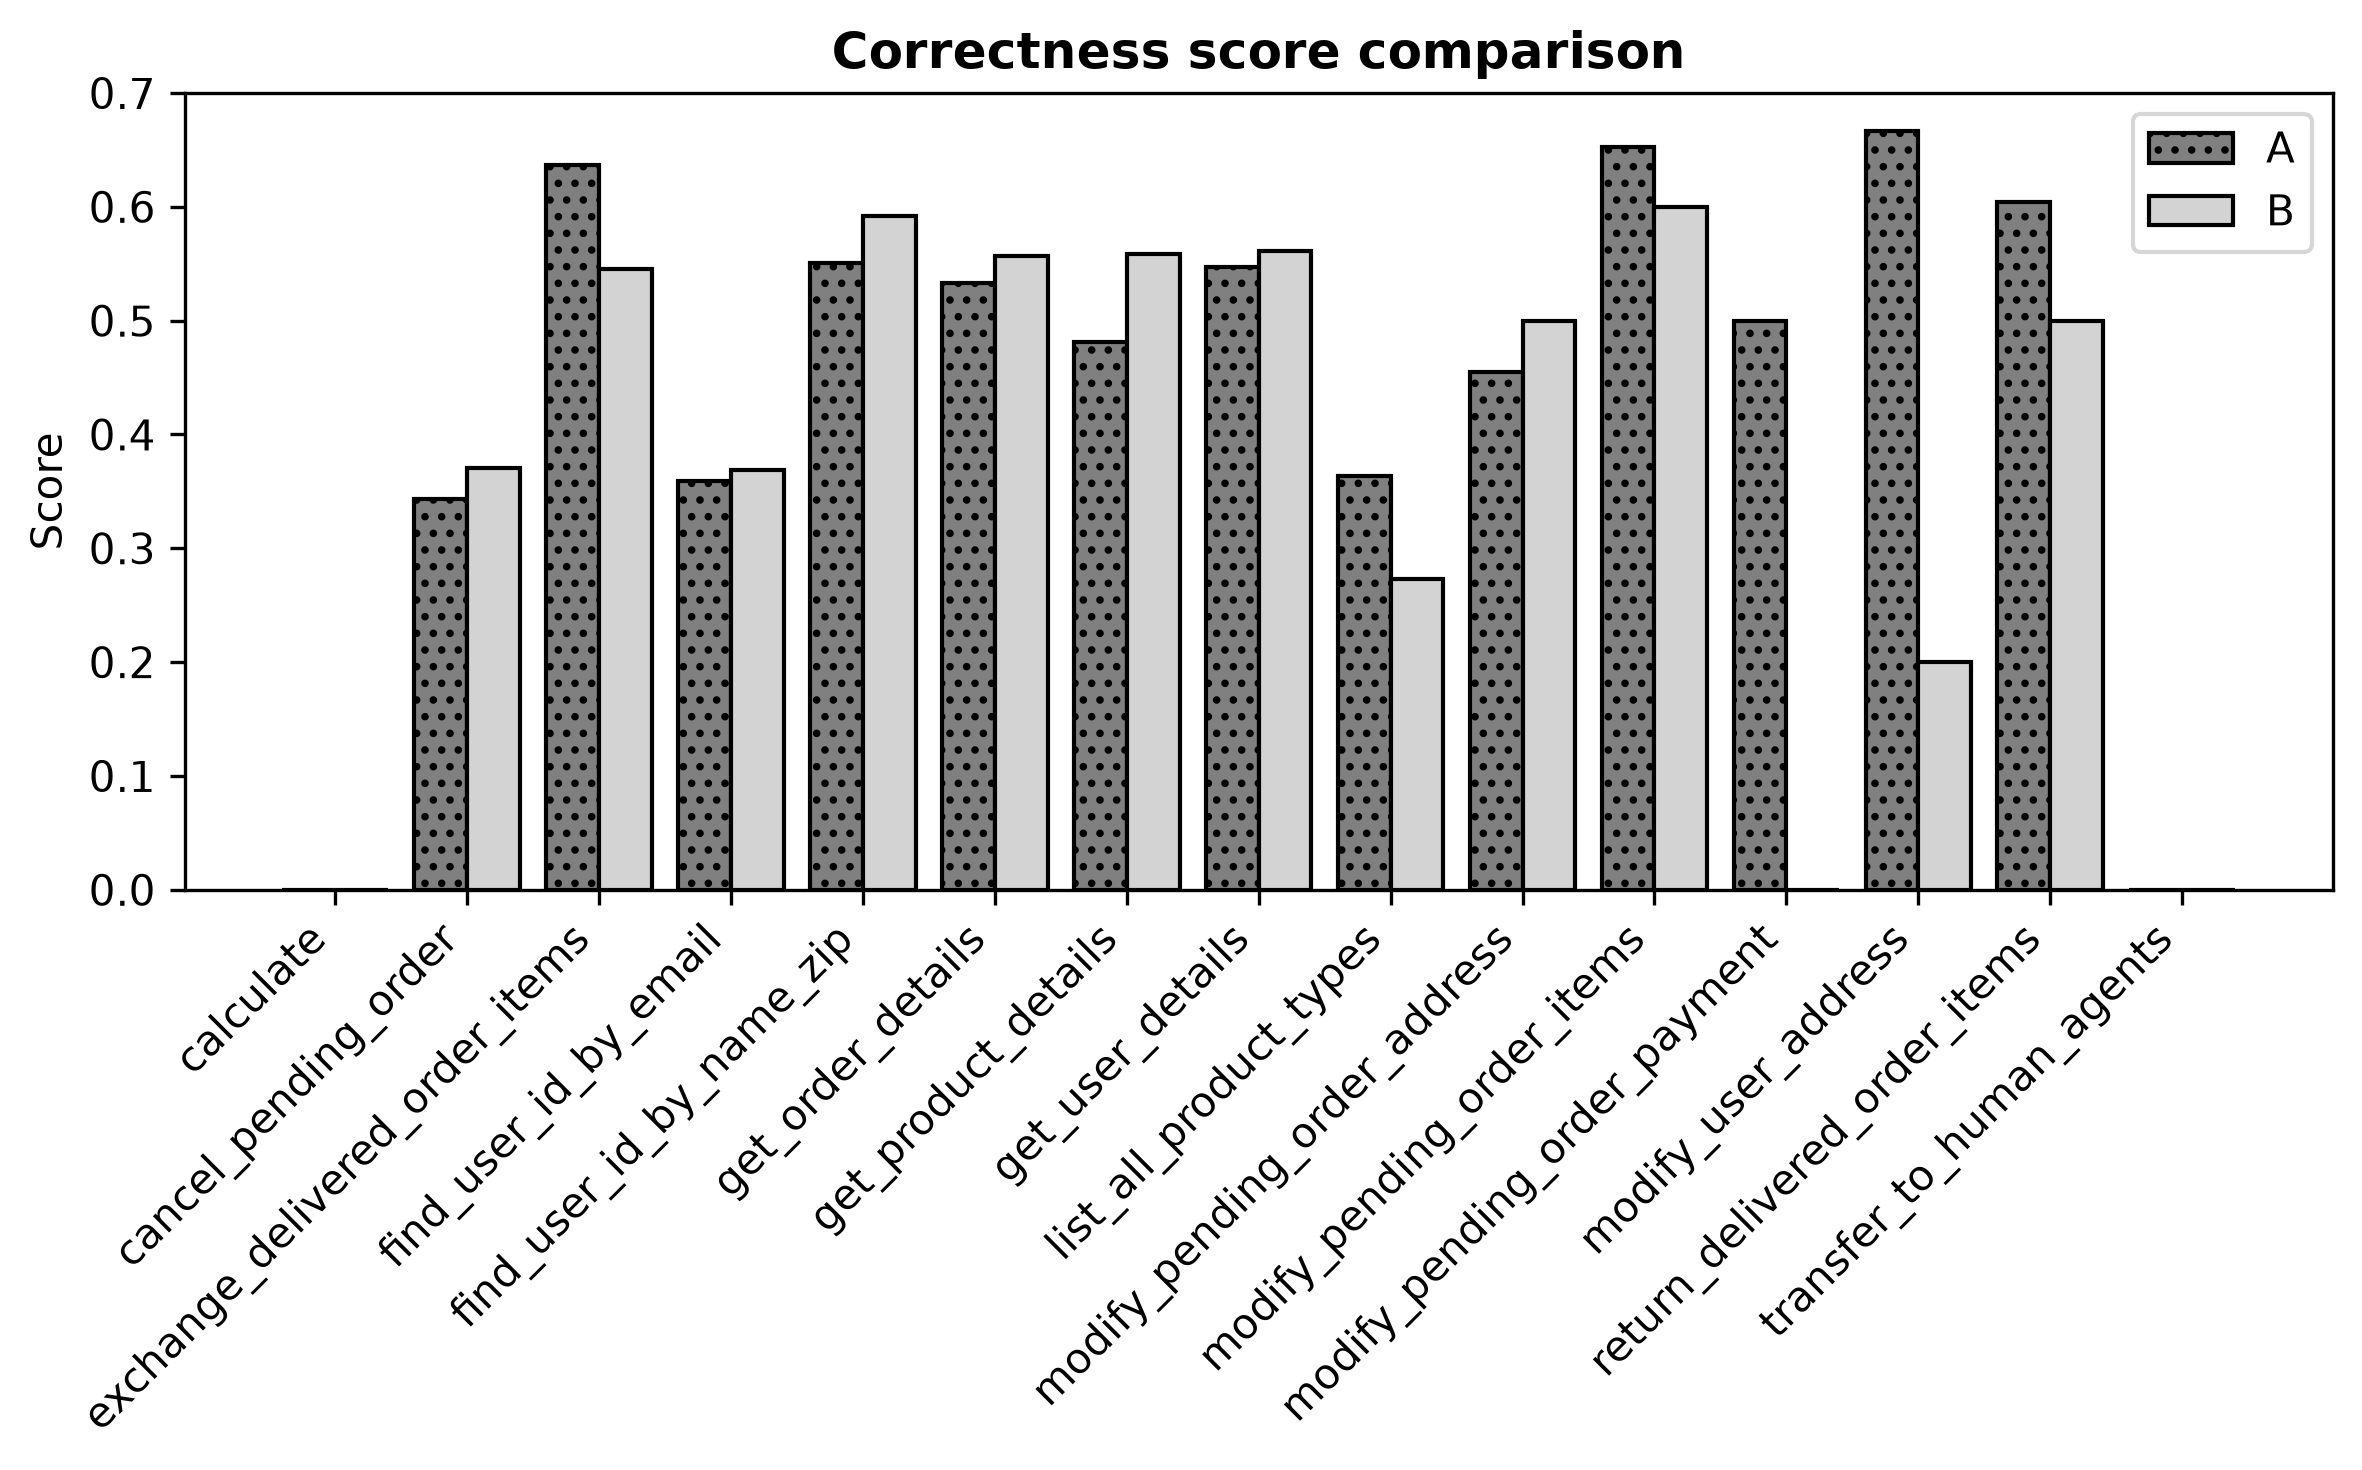

In [56]:
plot_compare_correctness_score(data_a, data_b)

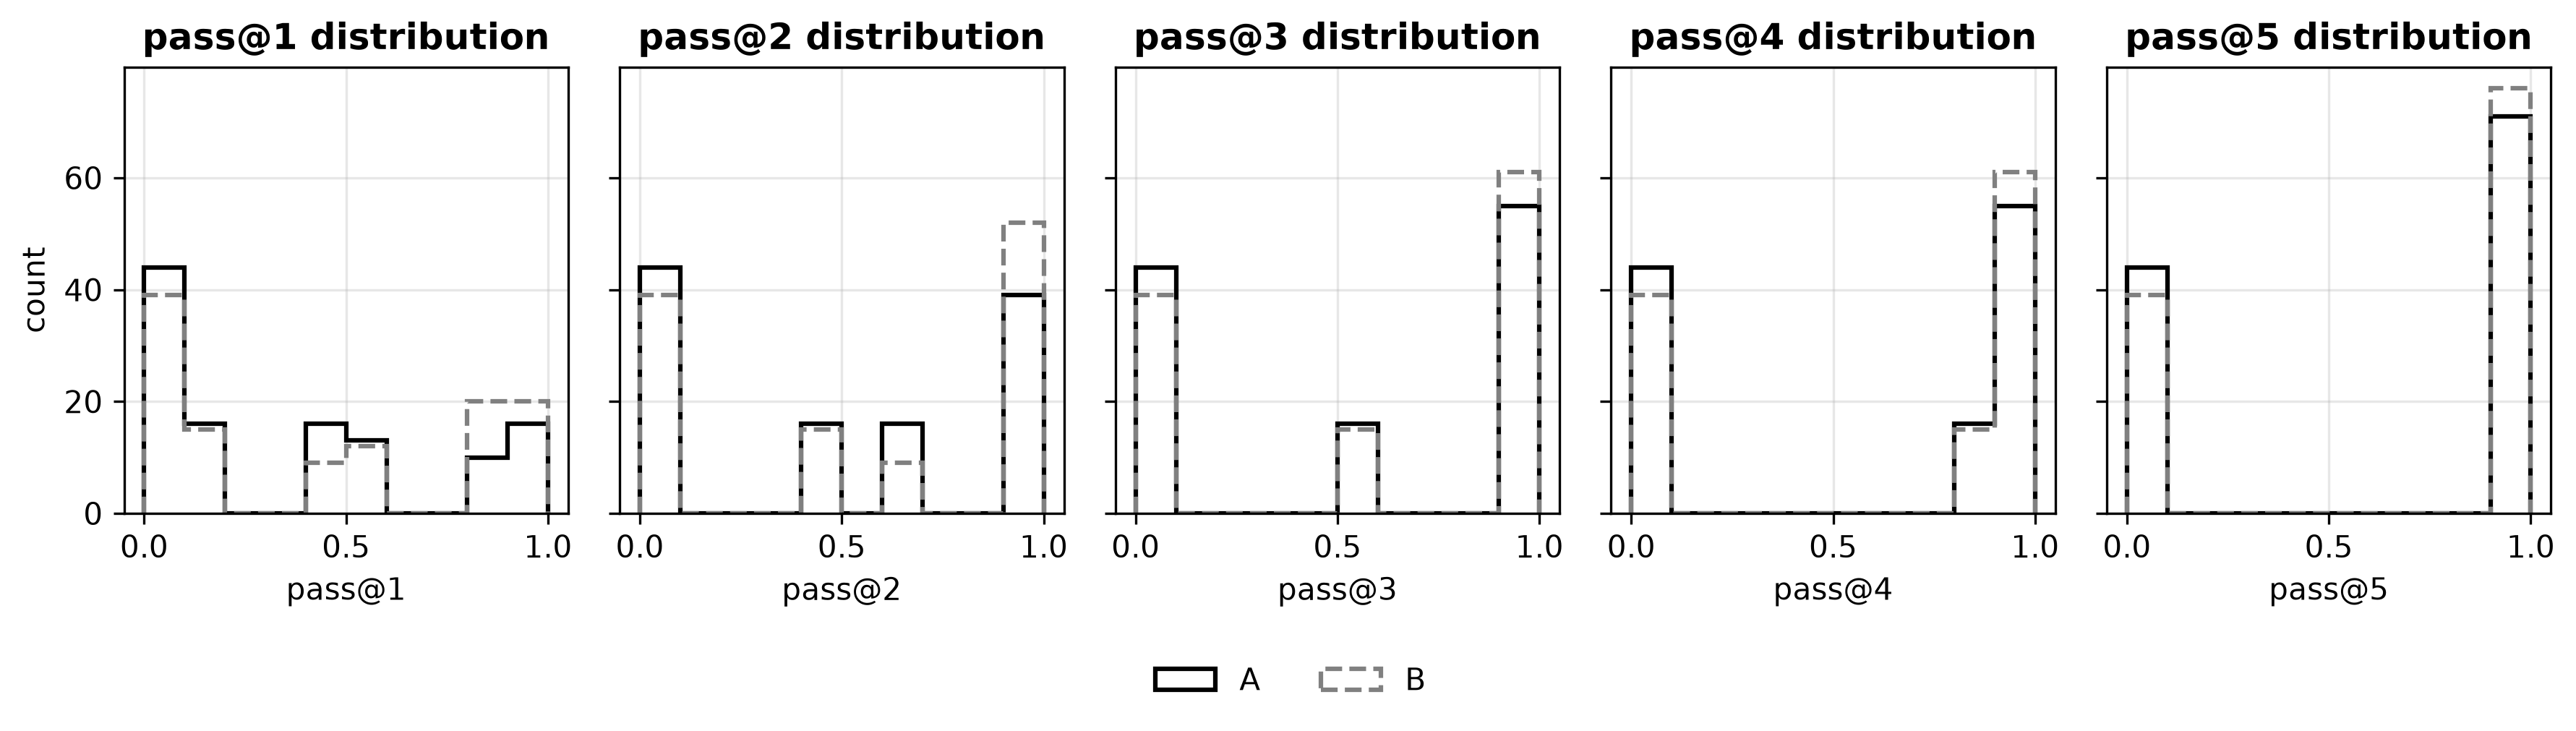

In [60]:
plot_compare_pass_at_k_dist(data_a, data_b, k_num=5)

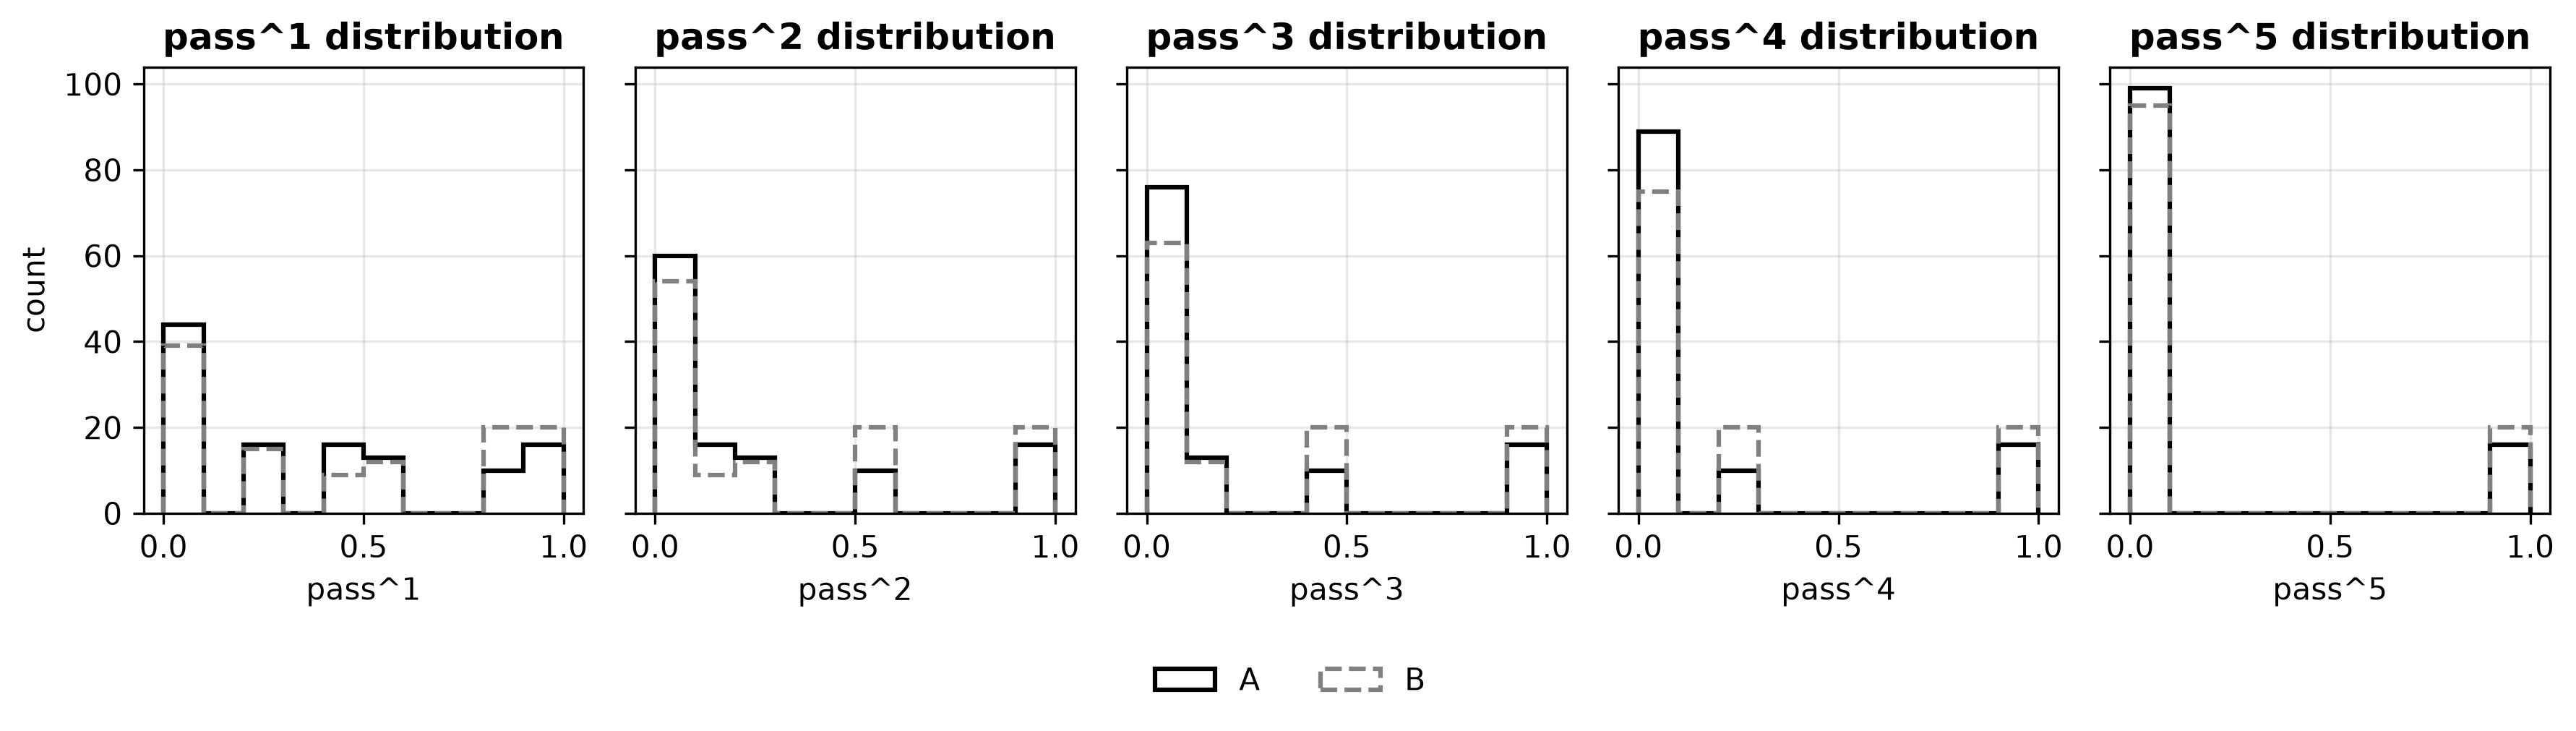

In [62]:
plot_compare_pass_hat_k_dist(data_a, data_b, k_num=5)

---

### Experimental

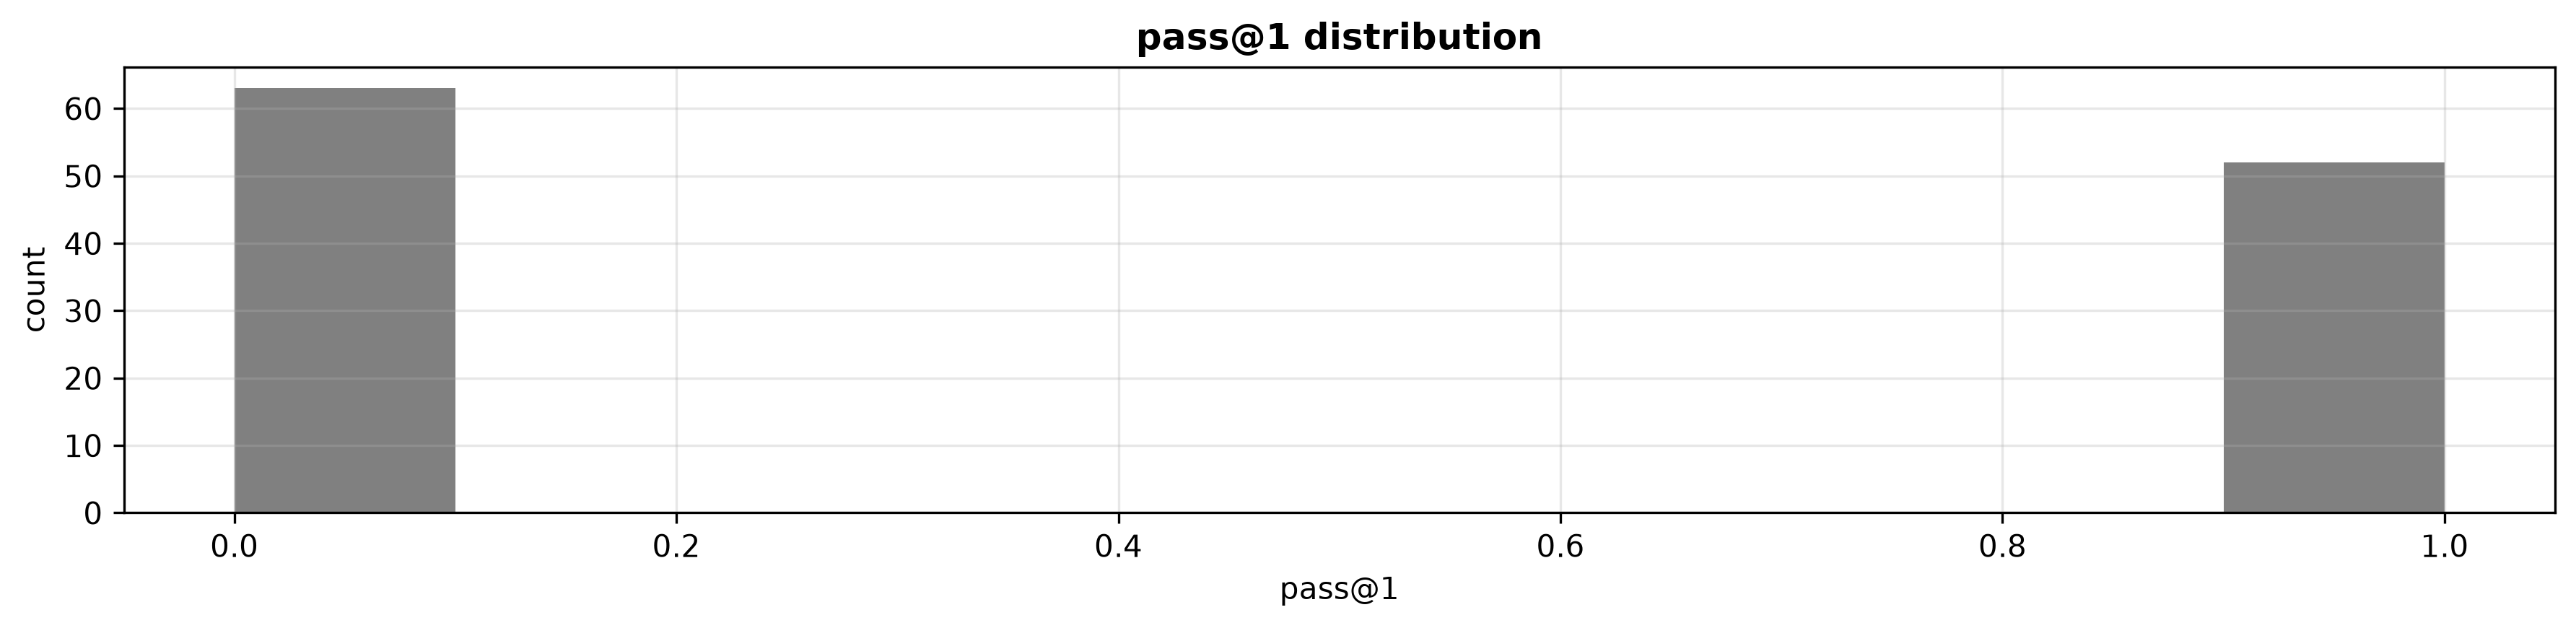

In [83]:
plot_pass_at_k_dist(evaluate([react_1]))

In [70]:
eval_react_12345.keys()

dict_keys(['tasks', 'correctness', 'reward'])